In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import helper_utils_nature_classification

In [17]:
# Device configuration
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


In [18]:
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

In [19]:
# Training set transformation pipeline
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

# Validation set transformation pipeline
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

In [20]:
subset_target_classes = [
    # Flowers
    'orchid', 'poppy', 'sunflower',
    # Mammals
    'fox', 'raccoon', 'skunk',
    # Insects
    'butterfly', 'caterpillar', 'cockroach'
]

In [21]:
train_dataset_proto, val_dataset_proto = helper_utils_nature_classification.load_cifar100_subset(subset_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 9 classes...
Filtering complete. Returning training and validation datasets.


In [22]:
# Set the number of samples to be processed in each batch
batch_size = 64

# Create a data loader for the training set, with shuffling enabled
train_loader_proto = DataLoader(train_dataset_proto, batch_size=batch_size, shuffle=True)

# Create a data loader for the validation set, without shuffling
val_loader_proto = DataLoader(val_dataset_proto, batch_size=batch_size, shuffle=False)

### building the CNN architecture

In [23]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # define the first convolutional block
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # define the second convolutional block
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # define the third convolutional block
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # define the layer to flatten the feature maps
        self.flatten = nn.Flatten()

        # define the fully connected linear layers
        self.fc1 = nn.Linear(128*4*4, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)


        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [24]:
# creating an instance of the model for the prototype

num_classes = len(train_dataset_proto.classes)
prototype_model = SimpleCNN(num_classes)

In [25]:
# before starting the training process it wil be helpful to visualize how the shape of the data changes as it flows through the CNN

def print_data_flow(model):
    # creating a sample input tensor (batch_size, channels, height, width)
    x = torch.randn(1, 3, 32, 32)

    print(f"Input Shape: \t\t{x.shape}")

    x = model.conv1(x)
    print(f"After conv1: \t\t{x.shape}")
    x = model.relu1(x)
    x = model.pool1(x)
    print(f"After pool1: \t\t{x.shape}")

    x = model.conv2(x)
    print(f"After conv2: \t\t{x.shape}")
    x = model.relu2(x)
    x = model.pool2(x)
    print(f"After pool2: \t\t{x.shape}")

    x = model.conv3(x)
    print(f"After conv3: \t\t{x.shape}")
    x = model.relu3(x)
    x = model.pool3(x)
    print(f"After pool3: \t\t{x.shape}")

    x = model.flatten(x)
    print(f"After Flatten: \t\t{x.shape}")

    x = model.fc1(x)
    print(f"After fc1: \t\t{x.shape}")

    x = model.relu4(x)
    x = model.dropout(x)
    x = model.fc2(x)
    print(f"Output Shape (fc2): \t\t{x.shape}")

In [26]:
# printing the model's architecture
print(prototype_model)
print("\n--- Tracing Data Flow ---")
print(print_data_flow(prototype_model))

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)

--- Tracing Data Flow ---
Input Shape: 		torch.Size([1, 3, 32, 32])
After conv1: 		torch.Size([1, 32, 32, 32])
After pool1: 		torch.Size([1, 32, 16, 16])
After conv2: 		torch.Size([1, 64, 16, 16])
After pool2: 		t

### training the model

In [27]:
loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(prototype_model.parameters(), lr=0.001)

#### the training loop

In [30]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    model.to(device)

    # initialize lists to store the training and validation metrics
    train_losses = []
    val_losses = []
    val_accuracies = []

    print(f"Training on {num_epochs} epochs")
    for epoch in range(num_epochs):
        # set the model to training mode
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            #perform a forward pass to get model outputs
            outputs = model(images)
            # calculate the loss
            loss = loss_function(outputs, labels)
            # perform a backward pass to compute gradients
            loss.backward()
            # update the model parameters
            optimizer.step()

            # accumulate the training loss for the batch
            running_loss += loss.item() * images.size(0)


        # calculate the average training loss for the epoch
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)


        # set the model to evaluation mode
        model.eval()
        # initialize running validation loss and correct predictions count
        running_val_loss = 0.0
        correct = 0
        total = 0
        # disable gradient calculations for validation
        with torch.no_grad():
            # iterate over batches of the data in the validation loader
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                # perform a forward pass to get model outputs
                outputs = model(images)

                # calculate the validation loss for the batch
                val_loss = loss_function(outputs,labels)
                # accumulate the validation loss
                running_val_loss += val_loss.item() * images.size(0)

                # get the predicted class labels
                _, predicted = torch.max(outputs, 1)
                # update the total numbers of samples
                total += labels.size(0)
                # update the number of correct predictions
                correct += (predicted == labels).sum().item()

            # calculate the average validation loss for the epoch
            epoch_val_loss = running_val_loss / len(val_loader.dataset)
            # append the epoch validation loss for the epoch
            val_losses.append(epoch_val_loss)

            #calculate the validation accuracy for the epoch
            epoch_accuracy = 100.0 * correct / total
            val_accuracies.append(epoch_accuracy)

            print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {epoch_loss:.4f}, Validation Loss: {epoch_val_loss:.4f}, Validation Accuracy: {epoch_accuracy:.2f}")


    print("-----Finished Training-----")

    metrics = [train_losses, val_losses, val_accuracies]

    # returned the trained model and the metrics calculated metrics during training
    return model, metrics

In [31]:
trained_proto_model, training_metrics_proto = training_loop(
    model=prototype_model,
    train_loader=train_loader_proto,
    val_loader=val_loader_proto,
    loss_function=loss_fn,
    optimizer=optimizer,
    num_epochs=15,
    device=device
)

Training on 15 epochs
Epoch [1/15], Training Loss: 0.4867, Validation Loss: 0.7210, Validation Accuracy: 76.89
Epoch [2/15], Training Loss: 0.4505, Validation Loss: 0.6656, Validation Accuracy: 79.11
Epoch [3/15], Training Loss: 0.4191, Validation Loss: 0.6995, Validation Accuracy: 79.11
Epoch [4/15], Training Loss: 0.3934, Validation Loss: 0.7139, Validation Accuracy: 78.89
Epoch [5/15], Training Loss: 0.3531, Validation Loss: 0.7041, Validation Accuracy: 79.11
Epoch [6/15], Training Loss: 0.3472, Validation Loss: 0.6813, Validation Accuracy: 80.33
Epoch [7/15], Training Loss: 0.3374, Validation Loss: 0.7230, Validation Accuracy: 78.22
Epoch [8/15], Training Loss: 0.3168, Validation Loss: 0.7621, Validation Accuracy: 79.56
Epoch [9/15], Training Loss: 0.2870, Validation Loss: 0.7499, Validation Accuracy: 79.22
Epoch [10/15], Training Loss: 0.2669, Validation Loss: 0.7293, Validation Accuracy: 80.78
Epoch [11/15], Training Loss: 0.2464, Validation Loss: 0.7364, Validation Accuracy: 81.

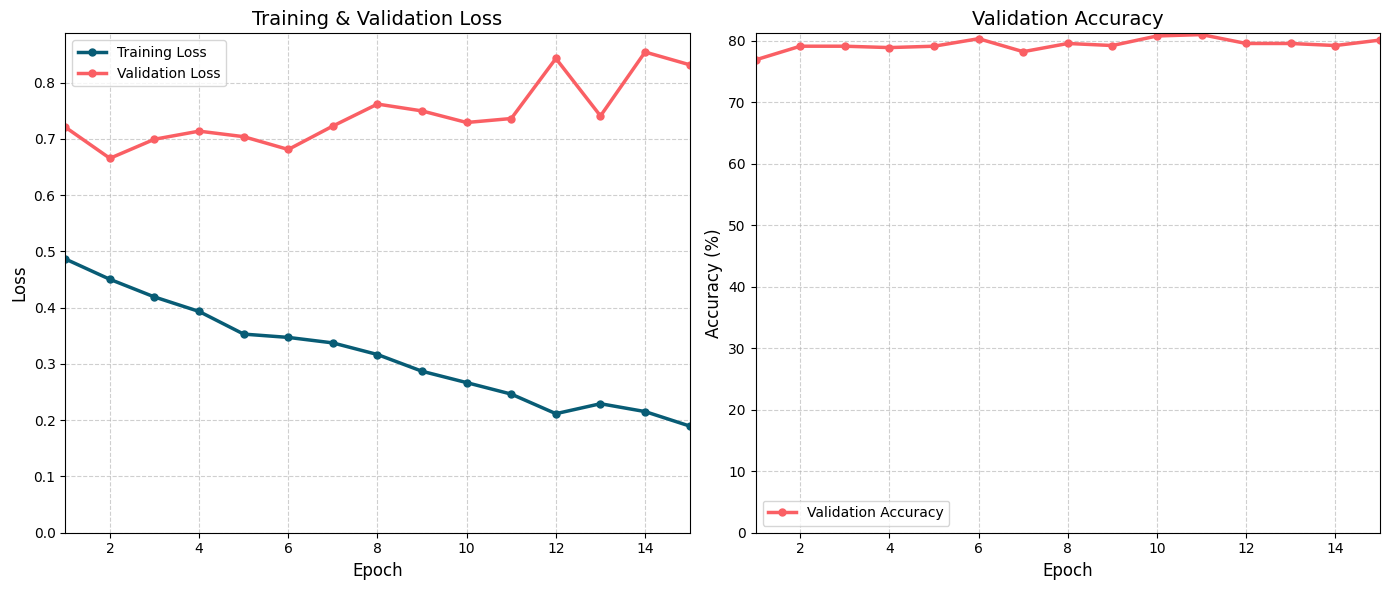

In [33]:
helper_utils_nature_classification.plot_training_metrics(training_metrics_proto)

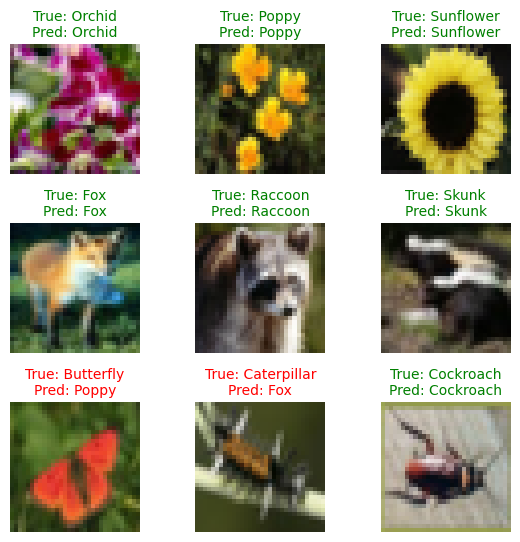

In [35]:
helper_utils_nature_classification.visualise_predictions(
    model=trained_proto_model,
    data_loader=val_loader_proto,
    device=device,
    grid=(3, 3)
)

In [37]:
# Define the full class list.
all_target_classes = [
    # Flowers
    'orchid', 'poppy', 'rose', 'sunflower', 'tulip',
    # Mammals
    'fox', 'porcupine', 'possum', 'raccoon', 'skunk',
    # Insects
    'bee', 'beetle', 'butterfly', 'caterpillar', 'cockroach'
]

# Load the full datasets.
train_dataset, val_dataset = helper_utils_nature_classification.load_cifar100_subset(all_target_classes, train_transform, val_transform)

Dataset found in './cifar_100'. Loading from local files.
Dataset loaded successfully.

Filtering for 15 classes...
Filtering complete. Returning training and validation datasets.


In [38]:
# Create a data loader for the training set, with shuffling enabled
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Create a data loader for the validation set, without shuffling
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [39]:
# Get the number of classes
num_classes = len(train_dataset.classes)

# Instantiate the full model
model = SimpleCNN(num_classes)

# Print the model's architecture (notice, it now has 15 output classes)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=15, bias=True)
)


In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

Training on 25 epochs
Epoch [1/25], Training Loss: 2.7088, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [2/25], Training Loss: 2.7090, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [3/25], Training Loss: 2.7092, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [4/25], Training Loss: 2.7095, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [5/25], Training Loss: 2.7093, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [6/25], Training Loss: 2.7101, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [7/25], Training Loss: 2.7097, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [8/25], Training Loss: 2.7096, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [9/25], Training Loss: 2.7091, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [10/25], Training Loss: 2.7094, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [11/25], Training Loss: 2.7087, Validation Loss: 2.7090, Validation Accuracy: 6.73
Epoch [1

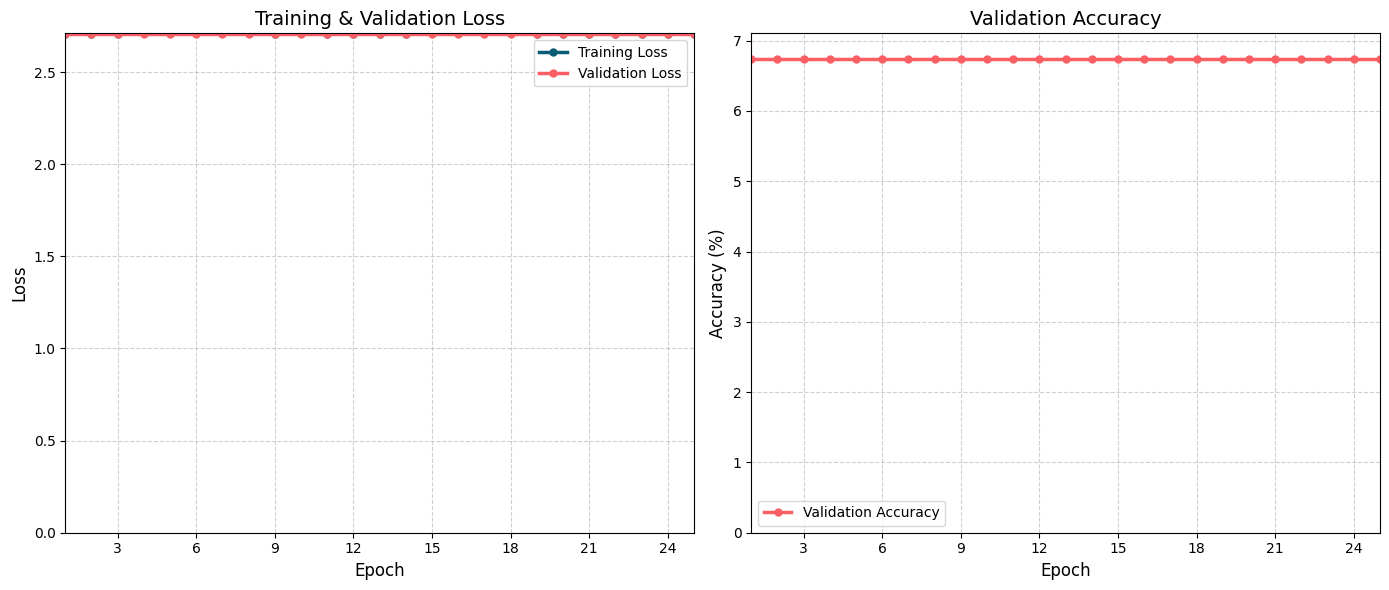

In [40]:
# Start the training process for the full model on all 15 classes
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_fn,
    optimizer=optimizer,
    num_epochs=25,
    device=device
)

# Visualize the training metrics for the full model
print("\n--- Training Plots ---\n")
helper_utils_nature_classification.plot_training_metrics(training_metrics)